# Poloidal mode spectrum scan of the plasma response
This tutorial is already an application of KiLCA and the interface. The idea is to scan the plasma response over poloidal mode numbers for a fixed toroidal mode number. The result is then plotted.

In [1]:
import sys
kil_in_path = '../'
sys.path.append(kil_in_path)
from KiLCA_interface import KiLCA_interface
from KiLCA_postprocessor import KiLCA_postprocessor
import numpy as np
import matplotlib.pyplot as plt

runpath = './runpath_pol_spec/'
run_type = 'flre' 
machine = 'AUG'  
prof_path = runpath + 'profiles/'
n_mode = 2
a = 63.5 #plasma radius

In [2]:
mode_max_min = 15
m_modes = np.linspace(-mode_max_min, mode_max_min, 2*mode_max_min+1, endpoint=True, dtype=int)

Br_flre = np.empty(0)
Br_vac = np.empty(0)

r_vac = np.empty(0)
r_flre = np.empty(0)

for m in m_modes:
    run_type = 'vacuum'
    kil_in = KiLCA_interface(33353, 2900, runpath, run_type, machine='AUG')
    kil_in.set_modes(m,n_mode)
    #kil_in.set_ASDEX(1)
    kil_in.antenna.data['flab'] = [1.0, 0.0]
    kil_in.write()
    kil_in.run()
    kil_post_vac = KiLCA_postprocessor(kil_in)

    kil_post_vac.read_EB(m=m,n=n_mode)
    kil_post_vac.EB_to_fields(kil_post_vac.EBdat, m=m, n=n_mode)
    if m== m_modes[0]:
        r_vac = kil_post_vac.r
    Br_vac = np.append(Br_vac, np.interp(r_vac, kil_post_vac.r, kil_post_vac.Br_real + 1j * kil_post_vac.Br_imag))

    run_type = 'flre'
    kil_in = KiLCA_interface(33353, 2900, runpath, run_type, machine='AUG')
    kil_in.set_modes(m,n_mode)
    #kil_in.set_ASDEX(1)
    kil_in.antenna.data['flab'] = [1.0, 0.0]
    kil_in.write()
    kil_in.run()
    kil_post = KiLCA_postprocessor(kil_in)

    kil_post.read_EB(m=m,n=n_mode)
    kil_post.EB_to_fields(kil_post.EBdat, m=m, n=n_mode)
    if m== m_modes[0]:
        r_flre = kil_post.r
    Br_flre = np.append(Br_flre, np.interp(r_flre, kil_post.r, kil_post.Br_real + 1j * kil_post.Br_imag))

Br_flre = Br_flre.reshape(mode_max_min*2+1, len(r_flre)).transpose()
Br_vac = Br_vac.reshape(mode_max_min*2+1, len(r_vac)).transpose()

Machine setting: AUG, type: vacuum
Single RMP mode: m = -15, n = 2
The KiLCA run took 1.0251080989837646s

Machine setting: AUG, type: flre
Single RMP mode: m = -15, n = 2
The KiLCA run took 3.235059976577759s

Machine setting: AUG, type: vacuum
Single RMP mode: m = -14, n = 2
The KiLCA run took 0.9346621036529541s

Machine setting: AUG, type: flre
Single RMP mode: m = -14, n = 2
The KiLCA run took 3.147740125656128s

Machine setting: AUG, type: vacuum
Single RMP mode: m = -13, n = 2
The KiLCA run took 1.2235305309295654s

Machine setting: AUG, type: flre
Single RMP mode: m = -13, n = 2
The KiLCA run took 3.166701078414917s

Machine setting: AUG, type: vacuum
Single RMP mode: m = -12, n = 2
The KiLCA run took 0.9935910701751709s

Machine setting: AUG, type: flre
Single RMP mode: m = -12, n = 2
The KiLCA run took 3.1155216693878174s

Machine setting: AUG, type: vacuum
Single RMP mode: m = -11, n = 2
The KiLCA run took 0.9589166641235352s

Machine setting: AUG, type: flre
Single RMP mode

In [3]:
q_dat = np.loadtxt('./runpath_pol_spec/profiles/q.dat')

r_res = np.zeros(mode_max_min)
m_pos = np.zeros(mode_max_min)
count = 0
for m in m_modes:
    if m > 1:
        r_res[count] = np.interp(m/n_mode, np.abs(q_dat[:,1]), q_dat[:,0])
        m_pos[count] = m
        count = count +1

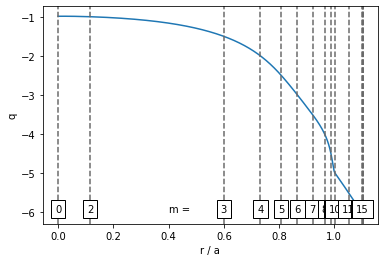

In [19]:
plt.figure()
plt.plot(q_dat[:,0] / a,q_dat[:,1])
count = 0
for res in r_res:
    plt.axvline(res / a, ls='--', c ='dimgrey')
    plt.text(res / a, -6, str(int(m_pos[count])), ha='center', bbox=dict(facecolor= 'w'))
    count = count + 1
plt.text(0.4, -6, 'm = ')
plt.xlabel('r / a')
plt.ylabel('q')
plt.show()

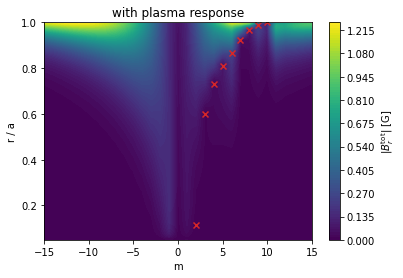

In [5]:
plt.figure()
uind = 420
cont = plt.contourf(m_modes, r_flre[0:uind] / a, np.abs(Br_flre[0:uind, :]), levels=100)
#plt.contour(m_modes, r_flre[0:uind] / a, np.abs(Br_flre[0:uind, :]), levels=100, cmap='Greys')
plt.colorbar(cont, label=r'$|B_r^{\rm tot}|$ [G]')
plt.scatter(m_pos, r_res/a, marker='x', c='tab:red')
plt.title('with plasma response')

plt.xlabel('m')
plt.ylabel('r / a')
plt.ylim(0.05,1.0)
plt.show()

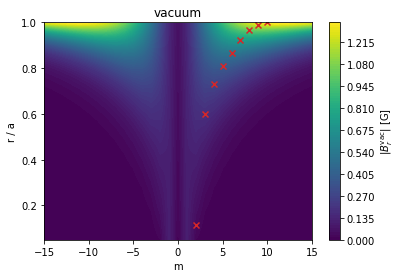

In [6]:
plt.figure()

uind = 940
cont = plt.contourf(m_modes, r_vac[0:uind] / a, np.abs(Br_vac[0:uind, :]), levels=100)
plt.colorbar(cont, label=r'$|B_r^{\rm vac}|$ [G]')
plt.scatter(m_pos, r_res/a, marker='x', c='tab:red')
plt.title('vacuum')

plt.xlabel('m')
plt.ylabel('r / a')
plt.ylim(0.05,1.0)
plt.show()

In [8]:
m_pos

array([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
       15.,  0.])